In [4]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


# US Consulate Sensor 2018 - 2022

In [6]:
import pandas as pd

input_file = "data/hcmc_lstm_ready.csv"  
df = pd.read_csv(input_file)
df.head()

,datetime,value,lag_1h,lag_2h,lag_3h,lag_24h,lag_168h,roll_mean_24h,roll_std_24h,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos
0,2018-01-08 07:00:00,21.0,19.0,23.0,16.0,15.000000,32.000000,18.291667,10.186338,0.965926,-0.258819,0.0,1.0,0.5,0.866025
1,2018-01-08 08:00:00,23.0,21.0,19.0,23.0,15.333333,24.000000,18.611111,10.209717,0.866025,-0.500000,0.0,1.0,0.5,0.866025
2,2018-01-08 09:00:00,20.0,23.0,21.0,19.0,15.666667,27.000000,18.791667,10.193686,0.707107,-0.707107,0.0,1.0,0.5,0.866025
3,2018-01-08 10:00:00,18.0,20.0,23.0,21.0,16.000000,24.000000,18.875000,10.178035,0.500000,-0.866025,0.0,1.0,0.5,0.866025
4,2018-01-08 11:00:00,17.0,18.0,20.0,23.0,14.000000,29.666667,19.000000,10.133886,0.258819,-0.965926,0.0,1.0,0.5,0.866025


In [7]:
df.isnull().sum()

datetime         0
value            0
lag_1h           0
lag_2h           0
lag_3h           0
lag_24h          0
lag_168h         0
roll_mean_24h    0
roll_std_24h     0
hour_sin         0
hour_cos         0
day_sin          0
day_cos          0
month_sin        0
month_cos        0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37665 entries, 0 to 37664
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   datetime       37665 non-null  object 
 1   value          37665 non-null  float64
 2   lag_1h         37665 non-null  float64
 3   lag_2h         37665 non-null  float64
 4   lag_3h         37665 non-null  float64
 5   lag_24h        37665 non-null  float64
 6   lag_168h       37665 non-null  float64
 7   roll_mean_24h  37665 non-null  float64
 8   roll_std_24h   37665 non-null  float64
 9   hour_sin       37665 non-null  float64
 10  hour_cos       37665 non-null  float64
 11  day_sin        37665 non-null  float64
 12  day_cos        37665 non-null  float64
 13  month_sin      37665 non-null  float64
 14  month_cos      37665 non-null  float64
dtypes: float64(14), object(1)
memory usage: 4.3+ MB


C:\Users\Admin\AppData\Local\Temp\ipykernel_21120\3680185822.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


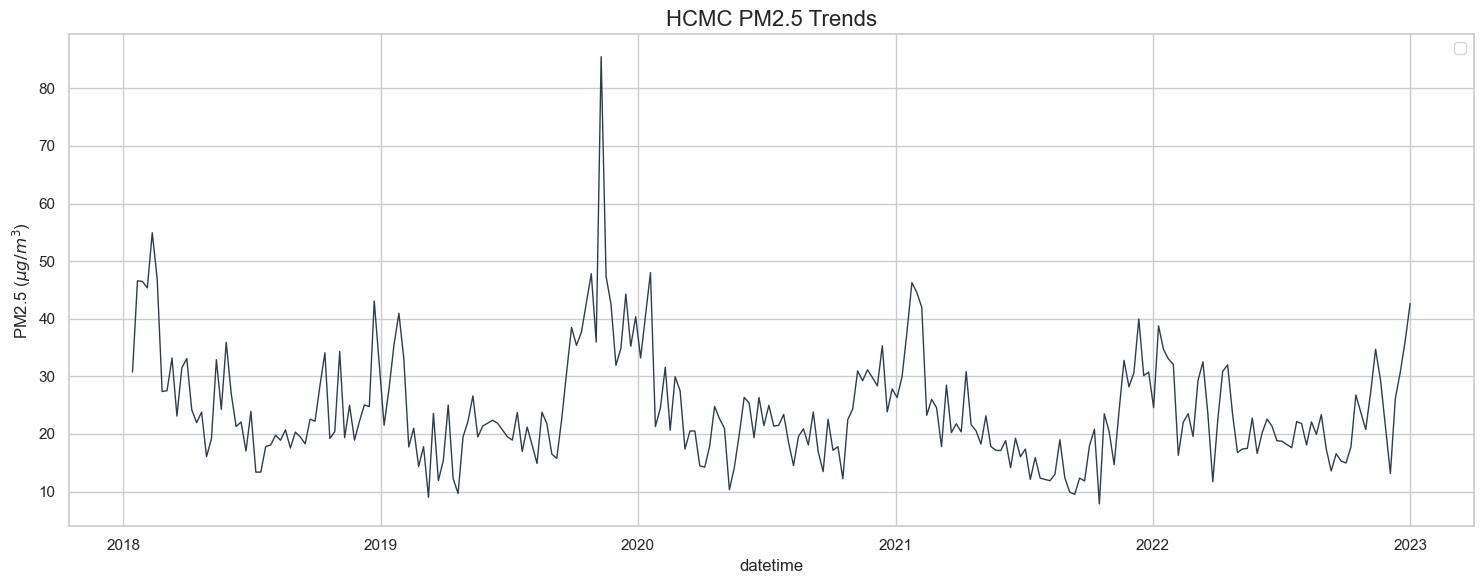

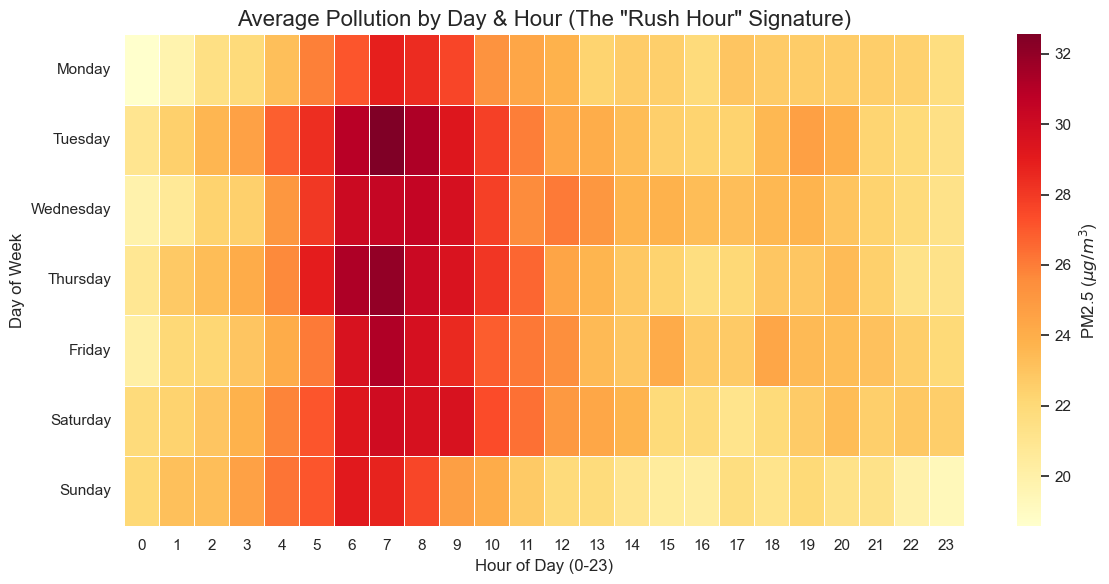

C:\Users\Admin\AppData\Local\Temp\ipykernel_21120\3680185822.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='month', y='value', palette="coolwarm", showfliers=False)


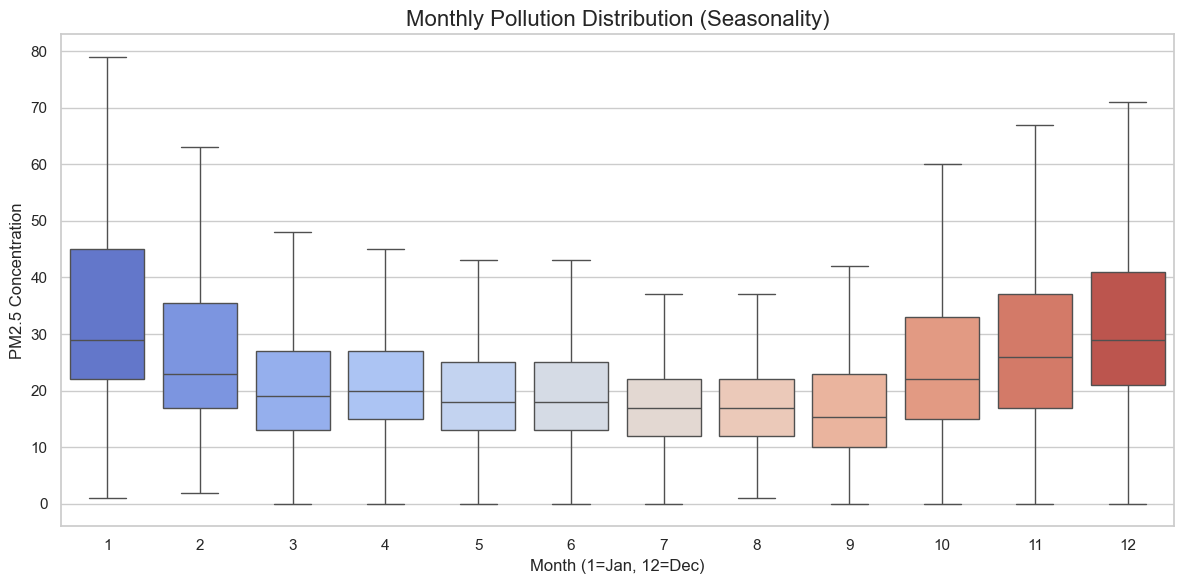

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def plot(input_file):

    df = pd.read_csv(input_file)
    df['datetime'] = pd.to_datetime(df['datetime'])

    df['year'] = df['datetime'].dt.year
    df['month'] = df['datetime'].dt.month
    df['hour'] = df['datetime'].dt.hour
    df['day_name'] = df['datetime'].dt.day_name()

    # Set the visual style
    sns.set_theme(style="whitegrid")

    # --- PLOT 1: THE 5-YEAR TIMELINE (The Big Picture) ---
    plt.figure(figsize=(15, 6))
    # Resample to Daily or Week or Month to make the plot readable (too much noise in hourly)
    daily_df = df.set_index('datetime').resample('W')['value'].mean().reset_index()

    sns.lineplot(data=daily_df, x='datetime', y='value', color='#2c3e50', linewidth=1)


    plt.title('HCMC PM2.5 Trends', fontsize=16)
    plt.ylabel('PM2.5 ($μg/m^3$)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- PLOT 2: "RUSH HOUR" HEATMAP---
    # We pivot the data: Rows = Day of Week, Columns = Hour of Day
    pivot_table = df.pivot_table(index='day_name', columns='hour', values='value', aggfunc='mean')

    # Reorder days to start on Monday
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    pivot_table = pivot_table.reindex(days_order)

    plt.figure(figsize=(12, 6))
    sns.heatmap(pivot_table, cmap="YlOrRd", linewidths=0.5, cbar_kws={'label': 'PM2.5 ($μg/m^3$)'})
    plt.title('Average Pollution by Day & Hour (The "Rush Hour" Signature)', fontsize=16)
    plt.xlabel('Hour of Day (0-23)')
    plt.ylabel('Day of Week')
    plt.tight_layout()
    plt.show()

    # --- PLOT 3: SEASONAL BOXPLOT (Rainy vs Dry Season) ---
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x='month', y='value', palette="coolwarm", showfliers=False)
    plt.title('Monthly Pollution Distribution (Seasonality)', fontsize=16)
    plt.xlabel('Month (1=Jan, 12=Dec)')
    plt.ylabel('PM2.5 Concentration')
    plt.tight_layout()
    plt.show()

plot(input_file)


# CMT8 Sensor

C:\Users\Eroz\AppData\Local\Temp\ipykernel_20472\3583645673.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


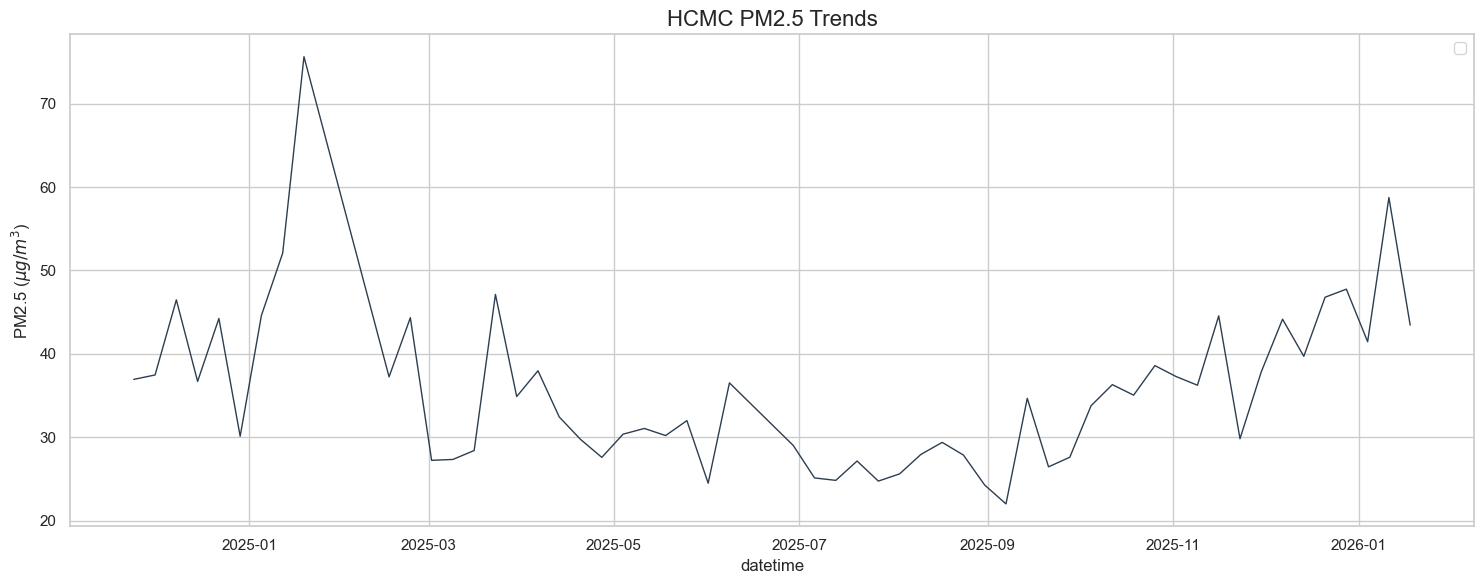

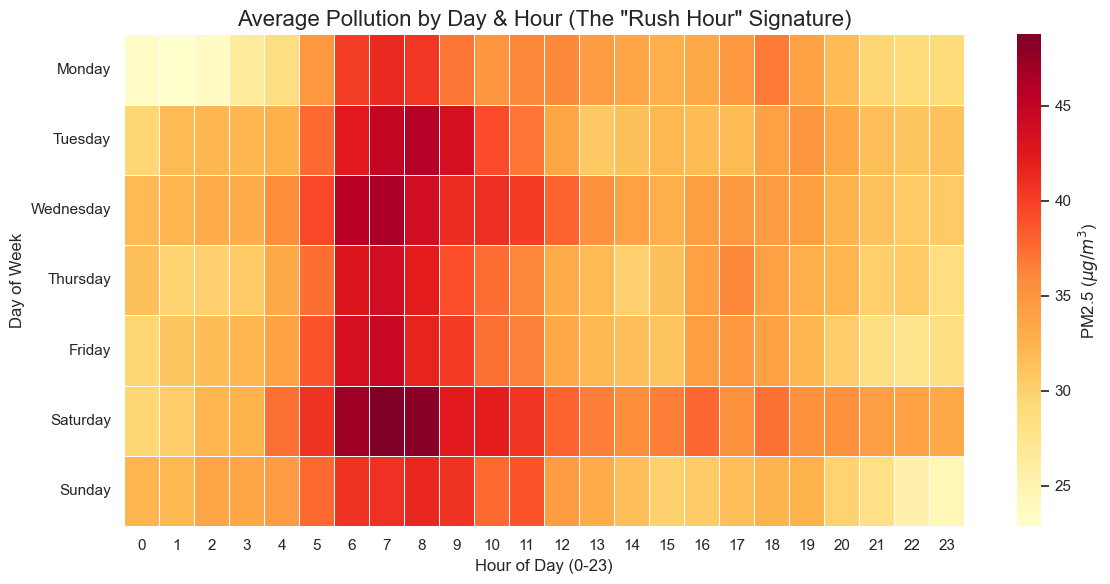

C:\Users\Eroz\AppData\Local\Temp\ipykernel_20472\3583645673.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='month', y='value', palette="coolwarm", showfliers=False)


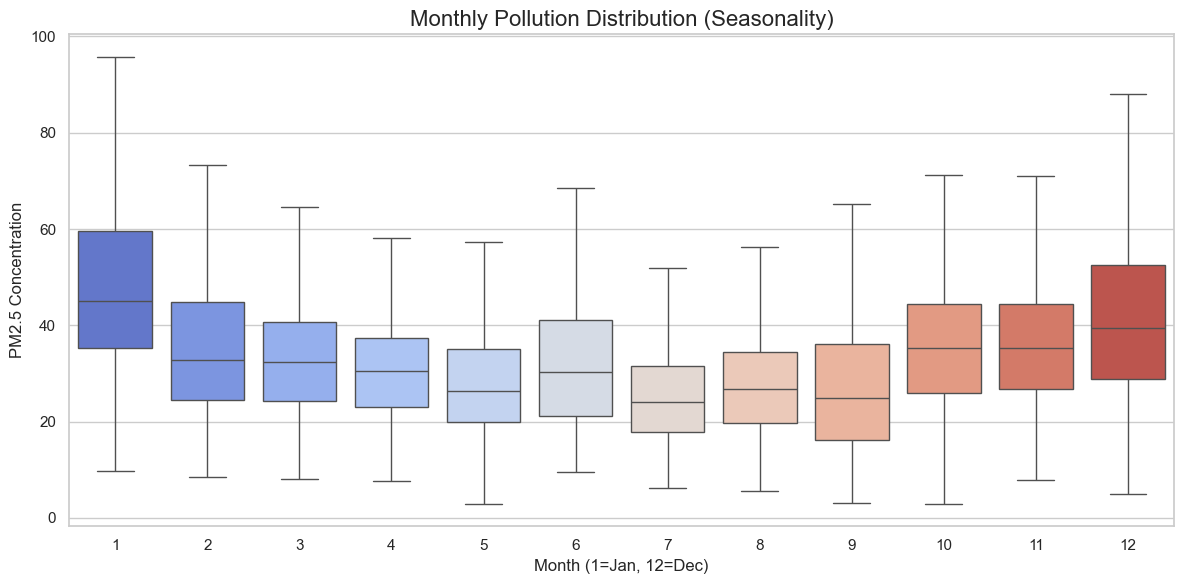

In [8]:
input_file = "hcmc_cmt8_cleaned_data.csv"
plot(input_file)